In [1]:
import igraph as ig

from agtools.core.unitig_graph import UnitigGraph

# Load the unitig-level assembly graph from the GFA file

In [2]:
ug = UnitigGraph.from_gfa("assembly_graph.gfa")

# Print basic graph-based statistics

In [3]:
print(f"Number of vertices (segments): {ug.vcount}")
print(f"Number of edges (links): {ug.ecount}")
print(f"Number of self-loops (repeats): {ug.self_loops}")
print(f"Average node degree: {ug.calculate_average_node_degree()}")
print(f"Number of connected components: {len(ug.get_connected_components())}")

Number of vertices (segments): 5
Number of edges (links): 5
Number of self-loops (repeats): []
Average node degree: 2
Number of connected components: 1


# Print basic sequence-based statistics

In [4]:
print(f"Total length of segments: {ug.calculate_total_length()}")
print(f"Average length of segments: {ug.calculate_average_segment_length()}")
print(f"GC content of segments: {ug.get_gc_content()}")
print(f"N50 and L50: {ug.calculate_n50_l50()}")

Total length of segments: 40
Average length of segments: 8
GC content of segments: 0.5
N50 and L50: (8, 3)


# Print oriented links

In [5]:
for from_link in ug.oriented_links:
    for to_link in ug.oriented_links[from_link]:
        for orient in ug.oriented_links[from_link][to_link]:
            print(from_link, orient[0], "->", to_link, orient[1])

1 + -> 2 +
2 - -> 1 -
2 + -> 3 +
2 + -> 4 +
3 - -> 2 -
3 + -> 5 +
4 - -> 2 -
4 + -> 5 +
5 - -> 3 -
5 - -> 4 -


# Print paths

In [6]:
for path in ug.paths:
    # Path name: path string, path overlaps
    print(f"{path}: {ug.paths[path][0]}\t{ug.paths[path][1]}")

path1: 1+,2+,3+,5+	7M,7M,7M
path2: 1+,2+,4+,5+	7M,7M,7M


# Get neighbours of a segment

In [7]:
print(f"Neighbours of segment 5: {ug.get_neighbors("5")}")

Neighbours of segment 5: ['3', '4']


# Print adjacency matrix

In [8]:
print("Adjancency matrix:")
print(ug.get_adjacency_matrix())

Adjancency matrix:
[[0, 1, 0, 0, 0]
 [1, 0, 1, 1, 0]
 [0, 1, 0, 0, 1]
 [0, 1, 0, 0, 1]
 [0, 0, 1, 1, 0]]


# Print segments

In [9]:
for seg_id in ug.segment_names:
    # internal segment ID, segment name, segment sequence, segment length
    print(seg_id, ug.segment_names[seg_id], ug.get_segment_sequence(ug.segment_names[seg_id]), ug.segment_lengths[ug.segment_names[seg_id]])

0 1 ACGTACGT 8
1 2 CGTACGTA 8
2 3 GTACGTAG 8
3 4 GTACGTAC 8
4 5 TACGTACC 8


# Plot the graph using igraph

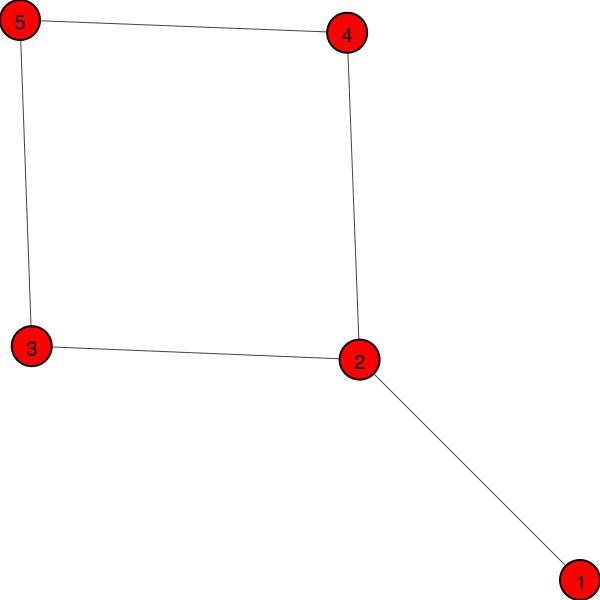

In [10]:
ig.plot(
    ug.graph,                           # graph object
    "graph_plot.png",                   # file name
    vertex_label=ug.graph.vs["name"],   # label names
    vertex_size=40,                     # vertex size
    vertex_frame_width=2.0,             #vertex frame width
    vertex_label_size=20.0,             # vertex label size
)